# Unidad 6 - Ajustes y Modelos

## Introducción

A lo largo de esta asignatura nos hemos dedicado a explorar, limpiar, transformar y visualizar datos. Todas esas herramientas tienen un propósito común: extraer información útil de los datos para entender mejor algún fenómeno del mundo real. En esta unidad damos un paso más: **aprendemos a construir modelos**.

Un modelo es una representación simplificada de un fenómeno que queremos estudiar. Al abstraer lo esencial y dejar de lado lo accesorio, un modelo nos permite ver con más claridad las relaciones entre las partes del fenómeno, que de otro modo quedarían ocultas en la complejidad del contexto. Esta idea es mucho más antigua que la ciencia de datos: los modelos matemáticos son una herramienta central en casi todas las disciplinas científicas y técnicas.

Un ejemplo célebre es el del arquitecto Antoni Gaudí, quien para diseñar los arcos de la Sagrada Familia construyó modelos físicos colgantes: una cadena suspendida de dos puntos forma, por efecto de la gravedad, una curva llamada *catenaria* que, invertida, describe la forma de arco con mayor resistencia estructural. Gaudí usó ese modelo físico —simple, manipulable— para entender y diseñar estructuras de gran complejidad.

```{figure} imagenes/sagrada-familia.jpg
---
width: 70%
align: center
---
La Sagrada Familia de Gaudí, por dentro.
```

En matemática y estadística encontramos la misma lógica. El libro *Cálculo de una Variable* de J. Stewart presenta un ejemplo ilustrativo: se dispone de mediciones de temperatura del aire a diferentes alturas sobre el nivel del suelo y se propone un modelo matemático que resume esa relación en una ecuación sencilla.

```{figure} imagenes/modelo-stewart.png
---
width: 35%
align: center
---
Modelo que expresa la temperatura $T$ (en °C) en función de la altura $h$ (en kilómetros).
```

Antes de llegar a esa ecuación, la situación de partida era simplemente una nube de puntos: pares de valores (altura, temperatura) sin ninguna estructura explícita. 

```{figure} imagenes/datos-modelo-stewart.png
---
width: 70%
align: center
---
Los datos recolectados que pudieron haber dado origen al modelo cuya ecuación se proporcionó en la figura anterior.
```

El modelo lineal transforma esa nube en una relación interpretable: permite predecir la temperatura a cualquier altura, cuantificar cuánto varía la temperatura por metro de ascenso, y comunicar ese conocimiento de forma compacta.

Esto es exactamente lo que haremos en esta unidad. Partimos de datos observados y construimos modelos que nos permitan explicar el comportamiento de una variable a partir de otras, predecir valores en situaciones no observadas, y cuantificar la magnitud y dirección de las relaciones entre variables.

Los modelos que estudiaremos son los siguientes:

- **Regresión lineal simple y múltiple:** el caso en que suponemos que la relación entre las variables puede representarse mediante una recta o un hiperplano. Es el punto de partida del aprendizaje estadístico supervisado.

- **Métodos de suavizado (*bin smoothing*, kernels, LOESS):** técnicas que estiman la forma de una relación sin imponerle una estructura paramétrica rígida.

- **Splines polinómicas:** funciones definidas por segmentos que combinan flexibilidad y suavidad, y que resuelven el problema del sobreajuste mediante un término de penalización.

En todos los casos, la pregunta central es la misma: dada la información disponible, ¿cuál es la mejor manera de representar la relación entre las variables? Y una vez construido el modelo, ¿cómo evaluamos qué tan bueno es?

## Análisis de Regresión

Bajo el nombre de **análisis de regresión** se engloba el conjunto de herramientas que permiten explicar —modelar matemáticamente— el comportamiento de una **variable respuesta $Y$** a partir de la información proporcionada por una o más **variables predictoras $X_1$, $X_2$, $\ldots$, $X_p$**.

La relación entre $Y$ y las $p$ variables predictoras 
p variables predictoras se expresa de la siguiente manera:

$$f(X_1, X_2, \ldots, X_p) + \varepsilon$$

donde:

- $f(\cdot)$ es una función fija pero desconocida que captura la relación sistemática entre las variables.

- $\varepsilon$ es el término de error aleatorio, que recoge todo aquello no incluido o explicitado en la parte sistemática del modelo: variables omitidas, variaciones no medibles, errores de medición, etc.

## Regresión lineal simple

### El modelo

Cuando es razonable suponer que la relación entre $Y$ y una única variable predictora $X$ es aproximadamente lineal, el modelo toma la forma:

$$Y = \underbrace{\beta_0 + \beta_1 X}_{f(X)} + \varepsilon$$

- $\beta_0$ es la **ordenada al origen**: el valor promedio o esperado de $Y$ cuando $X = 0$.

- $\beta_1$ es la **pendiente**: el cambio promedio en $Y$ cuando $X$ aumenta en una unidad.

A $\beta_0$ y $\beta_1$ se los denomina **parámetros** o **coeficientes** del modelo. Desde el punto de vista estadístico, la función de regresión $f(X) = \beta_0 + \beta_1 X$ representa la **esperanza condicional** de $Y$ dado $X$:

$$E[Y \mid X] = \beta_0 + \beta_1 X$$

Dado que $\beta_0$ y $\beta_1$ son desconocidos, debemos estimarlos a partir de los datos. A sus estimadores los denotamos $\hat{\beta}_0$ y $\hat{\beta}_1$ (recordar de Probabilidad y Estadística el sentido de la utilización del "sombrero" sobre un parámetro), y la recta ajustada resultante es:

$$\hat{y} = \hat{\beta_0} + \hat{\beta_1}x$$

### Ejemplo de trabajo

Contamos con datos sobre la superficie (en m<sup>2</sup>) y el precio de venta (en USD) de 10 departamentos:

In [1]:
from IPython.display import HTML, display
import pandas as pd

# Datos
datos = pd.DataFrame({
    'id':        [1,  2,  3,  4,   5,   6,   7,  8,   9,   10],
    'sup_m2':    [45, 60, 75, 90, 110, 130,  55, 80, 100,  120],
    'precio_usd':[82000, 97500, 128000, 155000, 190000, 225000,
                  97000, 124000, 185000, 210000]
})

# CSS + tabla HTML
html = f"""
<style>
.styled-table th {{
  background-color: #0f4954;
  color: white;
}}

.styled-table tr:nth-child(odd) {{
  background-color: white;
  color: #000;
}}

.styled-table tr:nth-child(even) {{
  background-color: #f2f8f9;
  color: #000;
}}

.styled-table {{
  border-collapse: collapse;
  border: 1px solid #0f4954;
  margin: 0 auto;
  font-family: Arial, sans-serif;
}}

.styled-table th,
.styled-table td {{
  border: 1px solid #b8d8de;
  padding: 8px 14px;
  text-align: center;
}}
</style>

{datos.to_html(index=False, classes="styled-table")}
"""

display(HTML(html))

id,sup_m2,precio_usd
1,45,82000
2,60,97500
3,75,128000
4,90,155000
5,110,190000
6,130,225000
7,55,97000
8,80,124000
9,100,185000
10,120,210000


Antes de ajustar cualquier modelo, conviene **visualizar** los datos para explorar la relación entre las variables.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datos
datos = pd.DataFrame({
    'id':        [1,  2,  3,  4,   5,   6,   7,  8,   9,   10],
    'sup_m2':    [45, 60, 75, 90, 110, 130,  55, 80, 100,  120],
    'precio_usd':[82000, 97500, 128000, 155000, 190000, 225000,
                  97000, 124000, 185000, 210000]
})

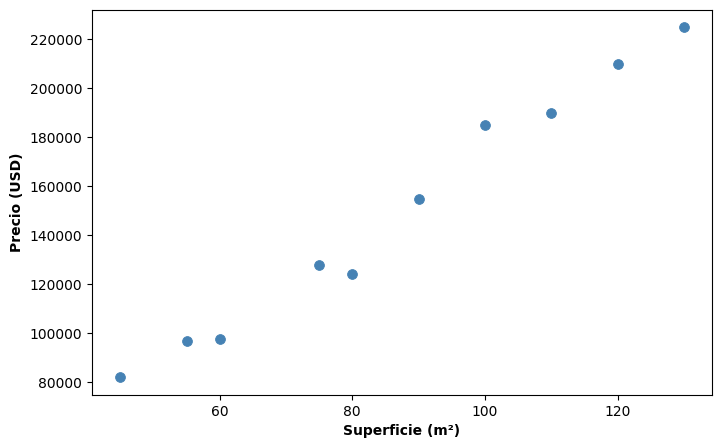

In [3]:
plt.figure(figsize = (8, 5))

sns.scatterplot(x = 'sup_m2', y = 'precio_usd', s = 50, color = 'steelblue', edgecolor = 'steelblue', data = datos)

plt.xlabel('Superficie (m²)', fontweight = 'bold')
plt.ylabel('Precio (USD)', fontweight = 'bold')

plt.show()

El gráfico muestra una aproximadamente lineal y directa o positiva: a mayor superficie ocupada por la propiedad, mayor precio de venta. Además, el mismo sugiere una relación intensa, lo que justifica proponer un modelo de regresión lineal simple.

En este contexto, la variable respuesta ($Y$) es el **precio de venta en USD**, mientras que la única predictora ($X$) en consideración es la **superficie en metros cuadrados**.

Intuitivamente, estimar los parámetros del modelo implicará encontrar la ecuación de la recta que mejor represente la relación entre el precio de venta y la superficie, en el sentido de que "mejor se ajuste" a la información que proporciona el conjunto de datos.

### Método de Mínimos Cuadrados Ordinarios (OLS)

Para estimar $\hat{\beta}_0$ y $\hat{\beta}_1$ necesitamos un criterio que defina qué significa que una recta "ajusta mejor" a los datos. Para ello introducimos el concepto de **residuo**.

#### Residuos

Dado el par observado $(x_i, y_i)$, el **valor ajustado** o predicho de la respuesta por el modelo es:

$$\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1\, x_i$$

El **residuo** asociado a la $i$-ésima observación es la distancia vertical entre el valor observado y el valor ajustado:

$$e_i = y_i - \hat{y}_i$$

Un residuo positivo indica que el modelo subestimó el valor real; un residuo negativo, que lo sobrestimó. Si los residuos son sistemáticamente grandes, la recta no ajusta bien.

<br>

El **Método de Mínimos Cuadrados Ordinarios (OLS)** consiste en encontrar los valores $\hat{\beta}_0$ y $\hat{\beta}_1$ que minimizan la sumatoria de los residuos del modelo al cuadrado y que se denomina **Suma de Cuadrados del Error** (SCE, o RSS por sus siglas en inglés):

$$\text{SCE} = \sum_{i=1}^{n} e_i^2 = \sum_{i=1}^{n} (y_i - \hat{\beta}_0 - \hat{\beta}_1\, x_i)^2 \longrightarrow \min$$

Dado que se trata de una función de las variables $\hat{\beta}_0$ y $\hat{\beta}_1$, para encontrar su mínimo calculamos ambas derivadas parciales, igualamos cada una a cero y resolvemos el sistema resultante (llamado **ecuaciones normales**). El resultado es:

$$\hat{\beta}_1 = \frac{\sum_{i=1}^{n} x_i y_i - n\,\bar{x}\,\bar{y}}{(n-1)\,s_x^2}$$

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\,\bar{x}$$

donde $\bar{x}$ y $\bar{y}$ son las medias muestrales de $X$ e $Y$, y $s_x^2$ es la varianza muestral de $X$.

### Ajuste en Python con **statsmodels**

Para realizar el ajuste en Python vamos a utilizar el módulo `statsmodels`, que provee herramientas para la estimación de modelos estadísticos, la realización de tests de hipótesis y la exploración de datos.

En particular, vamos a usar la interfaz de fórmulas `statsmodels.formula.api`, que permite especificar el modelo usando una sintaxis similar a la que emplean fórmulas análogas en R: `'variable_respuesta ~ variable_predictora'`. Esto hace que el código sea más legible.

In [4]:
import statsmodels.formula.api as smf

# Especificamos y ajustamos el modelo
## La fórmula 'precio_usd ~ sup_m2' le indica a statsmodels que:
####   - precio_usd es la variable respuesta (Y)
####   - sup_m2 es la variable predictora (X)
## El intercepto se incluye por defecto

modelo = smf.ols(formula = 'precio_usd ~ sup_m2', data = datos).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:             precio_usd   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     450.1
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           2.56e-08
Time:                        17:13:50   Log-Likelihood:                -101.82
No. Observations:                  10   AIC:                             207.6
Df Residuals:                       8   BIC:                             208.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3676.4706   7559.092     -0.486      0.6

La salida de `summary()` es una tabla completa con toda la información del ajuste. Por ahora nos concentramos en los coeficientes estimados, que aparecen en la sección central:

In [5]:
# Tabla de coeficientes
coef_table = modelo.summary2().tables[1]

# Función para formatear números grandes en notación científica
def fmt(x):
    return f"{x:.3e}" if abs(x) >= 10000 else f"{x:.3f}"

# Construir salida estilo statsmodels
output_coef = """
======================================================================================
                     coef    std err          t      P>|t|        [0.025      0.975]
--------------------------------------------------------------------------------------
"""

for idx, row in coef_table.iterrows():

    low = fmt(row['[0.025'])
    high = fmt(row['0.975]'])

    output_coef += (
        f"{idx:<12}"
        f"{row['Coef.']:>13.4f}"
        f"{row['Std.Err.']:>11.3f}"
        f"{row['t']:>11.3f}"
        f"{row['P>|t|']:>11.3f}"
        f"{low:>14}"
        f"{high:>13}\n"
    )

output_coef += "======================================================================================"

print(output_coef)


                     coef    std err          t      P>|t|        [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept      -3676.4706   7559.092     -0.486      0.640    -2.111e+04    1.375e+04
sup_m2          1769.0921     83.387     21.215      0.000      1576.801     1961.384


Cada fila corresponde a un coeficiente o parámetro del modelo. La columna `coef` es la que contiene las estimaciones.

La recta ajustada es entonces:

$$\hat{y} = -3676.5 + 1769.1\, x$$

**Interpretación de los coeficientes del modelo:**

- $\hat{\beta}_0 = -3676.5$: es el precio predicho cuando la superficie es 0 m^2^. Este valor no tiene interpretación práctica en este contexto: no existen departamentos de superficie nula. La ordenada al origen solo es interpretable cuando $X = 0$ tiene sentido en el dominio del problema y cuando el rango de valores de $X$ para el cual tenemos datos incluye al valor 0.

- $\hat{\beta}_1 = 1769.1$: por cada metro cuadrado adicional de superficie, el precio de la propiedad aumenta, en promedio, **1769.1 USD**. 

### Representar el ajuste

Para representar el modelo ajustado, mostraremos dos caminos:

#### Extrayendo manualmente los valores predichos

Un primer camino consiste en calcular los valores predichos por el modelo para cada observación del dataset, usando el método `predict`. Esto nos da control total sobre qué graficamos y cómo.

In [6]:
datos['predichos'] = modelo.predict(datos)
datos.head()

,id,sup_m2,precio_usd,predichos
0,1,45,82000,75932.675961
1,2,60,97500,102469.058143
2,3,75,128000,129005.440326
3,4,90,155000,155541.822509
4,5,110,190000,190923.665420


Con los valores predichos almacenados en el DataFrame, construimos el gráfico combinando un scatterplot con una línea que representa la recta ajustada:

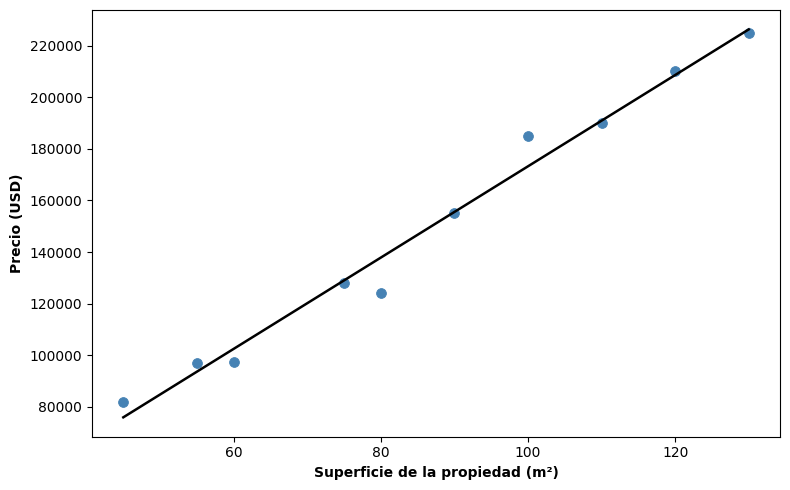

In [7]:
fig, ax = plt.subplots(figsize = (8, 5))

sns.scatterplot(x = 'sup_m2', y = 'precio_usd', data = datos,
                color = 'steelblue', edgecolor = 'steelblue', 
                s = 50, ax = ax)
sns.lineplot(x = 'sup_m2', y = 'predichos', data = datos,
             color = 'black', linewidth = 1.8, ax = ax)

ax.set_xlabel('Superficie de la propiedad (m²)', fontweight = 'bold')
ax.set_ylabel('Precio (USD)', fontweight = 'bold')

plt.tight_layout()
plt.show()

#### Utilizando la función **regplot** de seaborn

Una segunda opción, más directa, es usar `sns.regplot`, que en una sola llamada grafica los puntos, ajusta la recta de regresión y (opcionalmente) agrega una banda de confianza alrededor de ella.

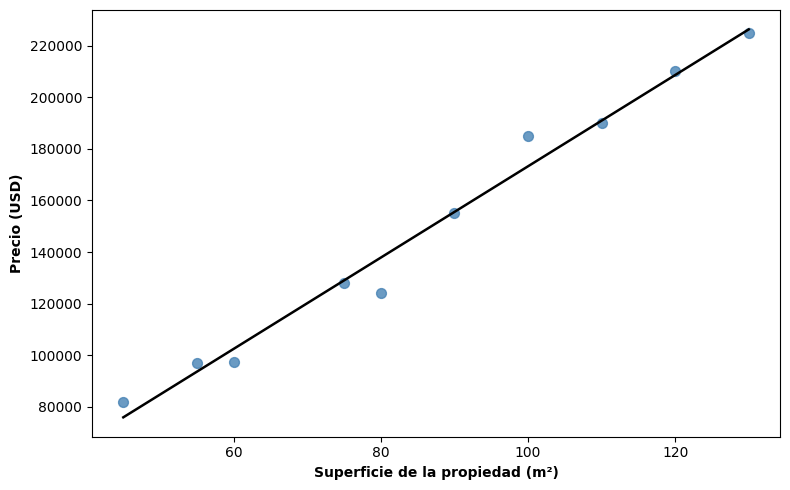

In [8]:
fig, ax = plt.subplots(figsize = (8, 5))

sns.regplot(x = 'sup_m2', y = 'precio_usd', data = datos,
            scatter_kws = {'color': 'steelblue', 'edgecolor': 'steelblue', 's': 50},
            line_kws = {'color': 'black', 'linewidth': 1.8},
            ci=None,   # quitamos banda de confianza)
            ax = ax)

ax.set_xlabel('Superficie de la propiedad (m²)', fontweight = 'bold')
ax.set_ylabel('Precio (USD)', fontweight = 'bold')

plt.tight_layout()
plt.show()

## Evaluación del modelo

Una vez ajustado el modelo, necesitamos métricas cuantitativas que nos permitan evaluar su desempeño bajo dos enfoques: qué tan bien explica la variabilidad de los datos históricos y qué tan preciso es al predecir la variable respuesta.

### Coeficiente de Determinación ($R^2$)

Una vez ajustado el modelo, queremos responder: **¿qué tan bien explica el modelo la variabilidad observada en $Y$?**

Para responder esa pregunta formalmente, primero pensemos en qué significa que haya variabilidad en la respuesta. En nuestro ejemplo, los precios de los departamentos no son todos iguales: van desde unos 82.000 USD hasta unos 225.000 USD. ¿Por qué? Podemos identificar dos fuentes:

- **Variabilidad explicada (capturada por el modelo):** parte de esa variabilidad se explica por las diferencias en superficie. Un departamento de 130 m<sup>2</sup> es más caro que uno de 45 m<sup>2</sup> precisamente porque la variable predictora recoge esa diferencia.

- **Variabilidad no explicada (el error):** la parte restante se debe a factores no incluidos en el modelo (ubicación, estado del inmueble, piso, número de ambientes, antigüedad, etc.) y a variaciones puramente aleatorias.

Una forma natural de cuantificar la variabilidad total en $Y$ es sumar las desviaciones al cuadrado de cada observación respecto de la media $\bar{y}$. A esta cantidad la llamamos **Suma de Cuadrados Total (SCT)**:

$$SCT = \sum_{i=1}^{n}(y_i - \bar{y})^2$$

Nótese que SCT es exactamente el numerador de la varianza muestral de $Y$: si se dividiera por $n−1$, obtendríamos $s_Y^2$. Es, por lo tanto, una medida de cuánto se dispersan los valores de la respuesta alrededor de su media, sin tener en cuenta ninguna variable predictora.

Puede demostrarse que esta variabilidad total se descompone de forma exacta en dos partes:

$$\underbrace{\sum_{i=1}^{n}(y_i - \bar{y})^2}_{\text{SCT: variab. total}} = \underbrace{\sum_{i=1}^{n}(\hat{y}_i - \bar{y})^2}_{\text{SCR: explicada por el modelo}} + \underbrace{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}_{\text{SCE: no explicada}}$$

donde:

- **SCR** (Suma de Cuadrados de la Regresión): mide cuánto se alejan los valores *predichos* $\hat{y}_i$ de la media $\bar{y}$. Si el modelo no aportara nada, todos los $\hat{y}_i$ serían iguales a $\bar{y}$ y la SCR sería cero. Cuanto mayor es la SCR, más está "haciendo" el modelo.

- **SCE** (Suma de Cuadrados del Error): es la suma de los residuos al cuadrado que ya conocemos. Representa lo que el modelo no logró explicar.

<br>

El **coeficiente de determinación** expresa la SCR como proporción de la SCT, es decir, qué fracción de la variabilidad total es explicada por el modelo:

$$R^2 = \frac{\text{SCR}}{\text{SCT}} = 1 - \frac{\text{SCE}}{\text{SCT}}$$

Su rango de variación es $0 \leq R^2 \leq 1$:

- $R^2 = 1$: ajuste perfecto, el modelo captura el 100% de la variabilidad en $Y$.

- $R^2 = 0$: el modelo no explica nada de la variabilidad en $Y$ (equivalente a usar la media $\bar{y}$ como predicción para todos los casos).

En nuestro ejemplo podemos obtenerlo directamente del objeto `modelo`:

In [9]:
print(f"R² = {modelo.rsquared:.4f}")

R² = 0.9825


Un $R^2 = 0.983$ indica que el 98.3% de la variabilidad en los precios de los departamentos queda explicada por la superficie. El 1.7% restante corresponde a factores no contemplados en el modelo.

```{admonition} **Advertencia importante**
:class: warning
Un $R^2$ alto no garantiza que el modelo sea adecuado. Puede ser elevado incluso cuando la relación entre las variables no es lineal, cuando hay valores atípicos influyentes, o cuando el modelo sobreajusta los datos. Siempre debe acompañarse de exploración gráfica y análisis de residuos.
```

La figura siguiente resume visualmente la lógica detrás del $R^2$. El panel superior muestra los errores al cuadrado cuando se predice $\bar{y}$ para todos los casos (es decir, ignorando completamente la variable predictora): esos cuadrados rosados representan la SCT. El panel inferior muestra los errores al cuadrado una vez ajustada la recta de regresión: esos cuadrados verdes, notoriamente más pequeños, representan la SCE. El $R^2$ es precisamente la proporción en que se redujeron los errores al pasar de un modelo sin predictores al modelo ajustado.

```{figure} imagenes/r2-graph.png
---
width: 70%
align: center
---
Análisis gráfico del $R^2$.
```

Nótese que la imagen usa la notación $SS_{tot}$ y $SS_{res}$ (del inglés *Sum of Squares Total* y *Sum of Squares Residual*), que son equivalentes a lo que en este texto llamamos SCT y SCE respectivamente.

```{admonition} **Recurso adicional**
:class: tip
Para una explicación visual adicional del $R^2$ y de la intuición detrás de su fórmula, se recomienda el siguiente [video](https://www.youtube.com/watch?v=2AQKmw14mHM) de StatQuest.
```

### Métricas de error
A diferencia del $R^2$, las siguientes métricas no miden proporciones, sino el tamaño promedio de nuestros errores de predicción en las unidades de la variable original.

#### Error Cuadrático Medio (MSE) y su Raíz (RMSE)

El **Error Cuadrático Medio** promedia los cuadrados de los residuos:

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = \frac{\text{SCE}}{n}$$

Al elevar los residuos al cuadrado, el MSE **penaliza fuertemente los errores grandes**. Su unidad es el cuadrado de la unidad de $Y$, lo que dificulta la interpretación directa.

La **Raíz del Error Cuadrático Medio** resuelve ese problema:

$$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

El RMSE está expresado en las **mismas unidades que $Y$** y es la métrica más utilizada en la práctica para reportar el error de predicción.

#### Error Absoluto Medio (MAE)

El **Error Absoluto Medio** promedia los valores absolutos de los residuos:

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

Al usar el valor absoluto en lugar del cuadrado, el MAE trata todos los errores de forma proporcional a su magnitud, sin penalizar especialmente los grandes. Por eso es **más robusto ante valores atípicos** que el RMSE. Se prefiere cuando el contexto no justifica penalizar más a los errores extremos.

#### Cálculo de métricas en Python
Para calcular estas métricas de error de forma automatizada, podemos recurrir al módulo `metrics` de la librería `scikit-learn` combinándolo con las predicciones del modelo:

In [10]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_obs  = datos['precio_usd']
y_pred = datos['predichos']

r2   = modelo.rsquared
mse  = mean_squared_error(y_obs, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_obs, y_pred)

print(f"""
R²   = {r2:.4f}
MSE  = {mse:,.2f} (USD²)
RMSE = {rmse:,.2f} (USD)
MAE  = {mae:,.2f} (USD)
""")


R²   = 0.9825
MSE  = 40,900,119.01 (USD²)
RMSE = 6,395.32 (USD)
MAE  = 4,519.28 (USD)



## Análisis de residuos

El análisis de residuos es una herramienta diagnóstica fundamental: permite verificar si las suposiciones del modelo lineal son razonables y si el ajuste es adecuado.

### Supuestos del modelo de regresión lineal

El modelo $Y = \beta_0 + \beta_1 X + \varepsilon$ descansa sobre supuestos acerca del término de error $\varepsilon$. Verificar que se cumplen es tan importante como ajustar el modelo: si alguno se viola, las estimaciones pueden ser sesgadas, los errores estándar incorrectos y toda inferencia sobre los parámetros, inválida.

1. **Linealidad**: la relación entre $X$ e $Y$ es efectivamente lineal, es decir, $f(X) = \beta_0 + \beta_1 X$ es una especificación correcta del modelo. Si la verdadera relación es curvilínea y ajustamos una recta, los residuos mostrarán un patrón sistemático en lugar de dispersarse aleatoriamente.

2. **Homocedasticidad**: la varianza del error es constante e igual a $\sigma^2$ para todos los valores de $X$:

$$\text{Var}(\varepsilon \mid X) = \sigma^2$$

   La violación de este supuesto se llama **heterocedasticidad** y se manifiesta, por ejemplo, cuando los residuos se vuelven más dispersos a medida que $\hat{y}$ crece (patrón de "embudo"). En ese caso, los errores estándar de los coeficientes son incorrectos y los tests de hipótesis no son válidos.

3. **Independencia**: los errores correspondientes a distintas observaciones son independientes entre sí, es decir, $\text{Cov}(\varepsilon_i,\varepsilon_j) = 0$ para $i \neq j$. Este supuesto suele violarse cuando los datos tienen una estructura temporal o espacial (por ejemplo, mediciones sucesivas sobre el mismo individuo).

4. **Normalidad**: los errores siguen una distribución normal con media cero y varianza $\sigma^2$:

$$\varepsilon \sim N(0, \sigma^2)$$

Este supuesto no es necesario para que las estimaciones OLS sean válidas, pero sí es indispensable para que los tests de hipótesis y los intervalos de confianza basados en la distribución $t$ sean válidos.

### Gráficos diagnósticos de residuos

En la práctica, los supuestos anteriores se verifican a través de los residuos del modelo. La idea es que si el modelo es correcto, los residuos $e_i = y_i - \hat{y}_i$ deben comportarse como una muestra de errores aleatorios: sin estructura, sin tendencia, y aproximadamente normales. Los dos gráficos diagnósticos más utilizados son los que se describen a continuación.

#### Residuos vs. valores ajustados

Este gráfico enfrenta los residuos $e_i$ contra los valores predichos $\hat{y}_i$. Permite detectar violaciones a los supuestos de linealidad y homocedasticidad:

- **Situación ideal:** los residuos se dispersan aleatoriamente alrededor de la línea horizontal $e=0$, sin ningún patrón visible. La curva suavizada (en rojo) debe ser aproximadamente horizontal y cercana al cero.

- **Patrón curvilíneo:** sugiere que la relación entre $X$ e $Y$ no es lineal y que el modelo está mal especificado.

- **Patrón de "embudo"** (varianza creciente o decreciente con $\hat{y}$): indica heterocedasticidad.

La curva suavizada (en rojo) que agrega `lowess = True` ayuda a detectar tendencias sistemáticas que podrían pasar desapercibidas a simple vista.

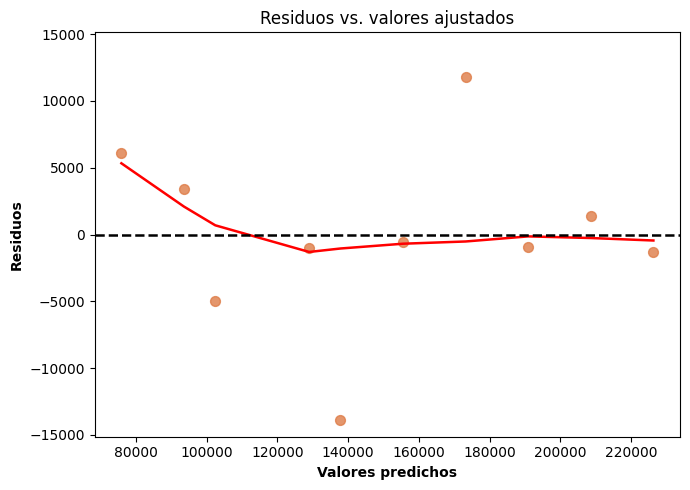

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.regplot(x = modelo.fittedvalues, y = modelo.resid,
            lowess = True,
            line_kws = dict(color = 'red', linewidth = 1.8),
            scatter_kws = dict(s = 50, edgecolor = '#de7c47', color = '#de7c47'),
            ax = ax)
ax.axhline(y = 0, color = 'black', linestyle = '--', linewidth = 1.8)
ax.set_xlabel('Valores predichos', fontweight = 'bold')
ax.set_ylabel('Residuos', fontweight = 'bold')
ax.set_title('Residuos vs. valores ajustados')

# Eje y simétrico alrededor del cero
low, high = ax.get_ylim()
bound = max(abs(low), abs(high))
ax.set_ylim(-bound, bound)

plt.tight_layout()
plt.show()

#### QQ-plot de los residuos

El gráfico cuantil-cuantil (*QQ-plot*) permite evaluar visualmente el **supuesto de normalidad** de los errores. En el eje horizontal se ubican los cuantiles teóricos de una distribución normal estándar. En el eje vertical, los cuantiles observados de los residuos estandarizados. Si los residuos provienen de una distribución normal, los puntos deben alinearse aproximadamente sobre la diagonal de referencia.

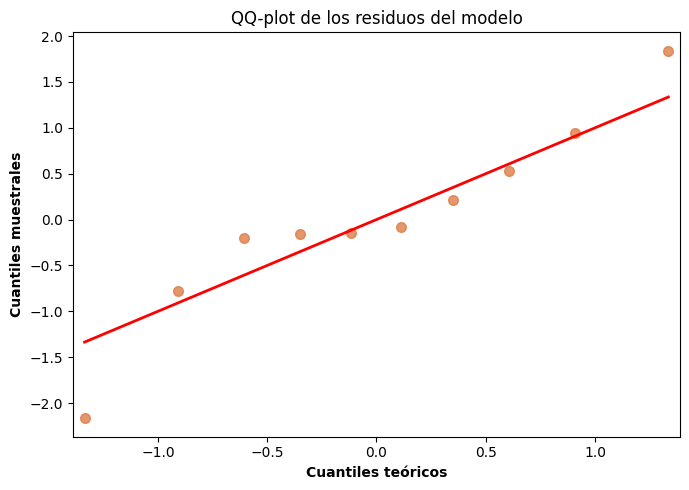

In [12]:
import statsmodels.api as sm

pp = sm.ProbPlot(modelo.resid, fit = True)

fig, ax = plt.subplots(figsize = (7, 5))
pp.qqplot(ax = ax, line = 's',
          marker = 'o',
          markerfacecolor = '#de7c47',
          markeredgecolor = '#de7c47',
          markersize = 7,
          alpha = 0.8)

ax.get_lines()[-1].set(color = 'red', linewidth = 2)

ax.set_xlabel('Cuantiles teóricos', fontweight = 'bold')
ax.set_ylabel('Cuantiles muestrales', fontweight = 'bold')
ax.set_title('QQ-plot de los residuos del modelo')

plt.tight_layout()
plt.show()

`line = 's'` traza la línea de referencia pasando por el primer y tercer cuartil de los datos (línea estandarizada), que es la opción más robusta para evaluar normalidad: no se ve afectada por valores extremos en las colas y es la convención más usada en la literatura estadística aplicada.

## Regresión lineal múltiple

En la práctica, la variable respuesta suele depender de más de una variable predictora. El modelo de regresión lineal múltiple extiende el caso simple incorporando $p$ predictores:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p + \varepsilon$$

La estimación de los coeficientes sigue el mismo principio OLS que en el caso simple: se buscan los valores $\hat{\beta_0}$, $\hat{\beta_1}$, $\ldots$, $\hat{\beta_p}$ que minimizan la SCE. En la práctica, nunca calcularemos estas estimaciones a mano: es lo que hace `statsmodels` internamente.

### Ejemplo: predicción de masa corporal en pingüinos del Archipiélago Palmer

Volvemos al dataset `penguins` para ajustar un modelo que prediga la masa corporal (`body_mass_g`) a partir de la longitud de la aleta (`flipper_length_mm`) y el sexo del animal (`sex`).

Desde la Unidad 3 sabemos que la relación entre ambas variables cuantitativas es lineal, intensa y de dirección positiva: los pingüinos más pesados tienden a tener aletas más largas. Eso nos da fundamento suficiente para construir un modelo para la masa corporal que considere a la longitud de la aleta como predictor. Pero, ¿tiene sentido incorporar también el sexo como predictor?

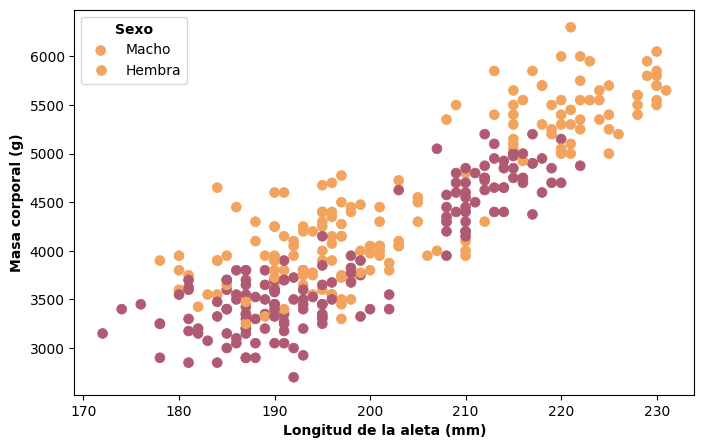

In [13]:
# Nos quedamos únicamente con los casos completos
data_penguins = sns.load_dataset('penguins').dropna()

# Definimos paleta de colores
colores = {'Female': '#B05A72','Male': '#F2A35E'}

plt.figure(figsize = (8,5))

sns.scatterplot(x = 'flipper_length_mm', y = 'body_mass_g', hue = 'sex', palette = colores, s = 50, data = data_penguins, edgecolor = None)

plt.xlabel('Longitud de la aleta (mm)', fontweight = 'bold')
plt.ylabel('Masa corporal (g)', fontweight = 'bold')

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(title = 'Sexo', labels = ['Macho', 'Hembra'], title_fontproperties = {'weight': 'bold'})

plt.show()

El gráfico muestra que, para una misma longitud de aleta, los pingüinos macho tienden a ser más pesados que las hembras. Esto sugiere que incorporar el sexo como predictor puede mejorar el ajuste respecto de un modelo simple.

Antes de incorporarlo, ajustemos el modelo que sólo incluye la longitud de la aleta como predictor:

In [14]:
# Ajustamos modelo de regresión lineal simple (un único predictor)
modelo1 = smf.ols(formula = 'body_mass_g ~ flipper_length_mm', data = data_penguins).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          3.13e-105
Time:                        17:13:51   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5872.0927    310.28

La ecuación del modelo ajustado es:

$$\hat{y} = -5872.1 + 50.2~x$$

Este modelo explica el 76.2% de la variabilidad en la masa corporal (R<sup>2</sup> = 0.762). Su representación gráfica:

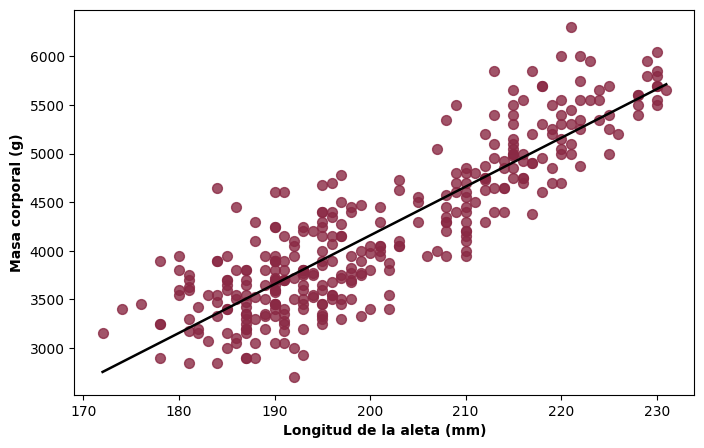

In [15]:
fig, ax = plt.subplots(figsize = (8, 5))

sns.regplot(x = 'flipper_length_mm', y = 'body_mass_g', data = data_penguins,
            scatter_kws = {'color': '#8a2944', 'edgecolor': None, 's': 50},
            line_kws = {'color': 'black', 'linewidth': 1.8},
            ci = None,
            ax = ax)

ax.set_xlabel('Longitud de la aleta (mm)', fontweight = 'bold')
ax.set_ylabel('Masa corporal (g)', fontweight = 'bold')

plt.show()

### Incorporar una variable cualitativa: variables *dummy*

Las variables predictoras no tienen por qué ser numéricas. Una variable cualitativa (o categórica) puede incorporarse al modelo mediante la creación de **variables indicadoras o *dummy***.

Para una variable con dos categorías (por ejemplo, el sexo del pingüino: `Male` / `Female`), se define una variable que toma el valor 1 para una de las categorías y 0 para la otra:

$$X_{2} = \begin{cases}
    1, & \text{si es un pingüino macho}.\\
    0, & \text{si es un pingüino hembra}.
  \end{cases}$$
  
La categoría codificada con 0 se denomina **categoría de referencia**: todos los coeficientes del modelo se interpretan en relación a ella. En este caso, la hembra es la referencia, de modo que $\beta_2$ mide cuánto difiere la masa corporal promedio de un macho respecto de una hembra *con la misma longitud de aleta*.

De este modo, el modelo con dos predictores queda:

$$Y = \beta_0 + \beta_1~X_1 + \beta_2~X_2 + \varepsilon$$

donde $X_1$ es la longitud de la aleta y $X_2$ es el sexo representado a través de la variable indicadora.

Podemos crear la variable dummy de varias maneras. Una posibilidad es usar una función *lambda*:

In [16]:
data_penguins['male_dummy'] = data_penguins['sex'].apply(lambda x: 1 if x == 'Male' else 0)

Otra es usar el método `get_dummies()` de Pandas. En ese caso hay que tener en cuenta dos cuestiones:

- El método genera una dummy por categoría (una para `Female` y otra para `Male`), pero sólo necesitamos $k − 1 = 1$, donde $k$ es el número de categorías de la variable categórica.

- La opción `drop_first = True` descarta la primera categoría en orden alfabético (`Female`), devolviendo únicamente la dummy para `Male`.

In [17]:
pd.get_dummies(data_penguins['sex'], drop_first = True)

,Male
0,True
1,False
2,False
4,False
5,True
...,...
338,False
340,False
341,True
342,False


```{admonition} **IMPORTANTE**
:class: warning
Si la variable categórica tiene $k$ niveles (por ejemplo, tres especies de pingüinos), se crean $k - 1$ variables dummy. Incluir las $k$ generaría **colinealidad perfecta** entre los predictores —conocida como la *trampa de las variables dummy*— porque la suma de todas las dummies sería siempre igual a 1, que es idéntica a la columna de la constante. La categoría excluida actúa como categoría de referencia y su efecto queda capturado en $\beta_0$.
```

Sin embargo, al usar `smf.ols` no es necesario crear la dummy manualmente: alcanza con incluir la variable categórica directamente en la fórmula. `statsmodels` genera las dummies automáticamente, tomando como referencia la primera categoría en orden alfabético (`Female` en este caso). Para agregar un predictor, se usa el símbolo `+` a la derecha del `~`:

In [18]:
modelo2 = smf.ols(formula = 'body_mass_g ~ flipper_length_mm + sex', data = data_penguins).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     684.8
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          3.53e-118
Time:                        17:13:51   Log-Likelihood:                -2427.2
No. Observations:                 333   AIC:                             4860.
Df Residuals:                     330   BIC:                             4872.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5410.3002    285.79

`statsmodels` nombra automáticamente la dummy como `sex[T.Male]`, indicando que representa el efecto de ser macho respecto de ser hembra. La ecuación del modelo ajustado es:

$$\hat{y} = -5410.3 + 46.98~x_1 + 347.85~x_2$$

#### Interpretación de los coeficientes

- $\hat{\beta_1} = 46.98$: por cada milímetro adicional de longitud de aleta, el modelo predice que la masa corporal aumenta, en promedio, 46.98 g, manteniendo constante el sexo del animal.

- $\hat{\beta_2} = 347.85$: el modelo ajustado predice que un pingüino macho pesa, en promedio, 347.85 g más que una hembra con la misma longitud de aleta. Este es el desplazamiento vertical entre las dos rectas ajustadas.

Nótese que el coeficiente de `flipper_length_mm` cambió, al pasar de 50.2 (Modelo 1) a 47.0 (Modelo 2). Esto es esperable: en el modelo simple, ese coeficiente absorbía parte del efecto del sexo (que está correlacionado con la longitud de la aleta); al controlarlo explícitamente, la estimación del efecto parcial de la aleta se ajusta.

#### Las rectas ajustadas son paralelas

Cuando se incorpora una variable dummy de forma aditiva, el modelo produce dos rectas paralelas: una para cada categoría, con la misma pendiente $\hat{\beta_1}$ pero distinta ordenada al origen. 

De acuerdo al valor que tome $x_2$ podemos diferenciar entre un modelo ajustado para machos y otro para hembras:

<div style="background-color:rgba(242,163,94,0.5);
padding:12px;
border-radius:8px;
margin-bottom:12px;
color:black;">

**Recta ajustada para pingüinos machos ($x_2 = 1$)**

$$
\hat{y} =
{−5062.45} +
{46.98}~x_{1}
$$

</div>

<div style="background-color:rgba(176,90,114,0.5);
padding:12px;
border-radius:8px;
color:black;">

**Recta ajustada para pingüinos hembra ($x_2 = 0$)**

$$
\hat{y} =
{−5410.3} +
{46.98}~x_{1}
$$

</div>
<br>

Representemos estas rectas gráficamente. Para ello, haremos uso del método `predict` presentado anteriormente.

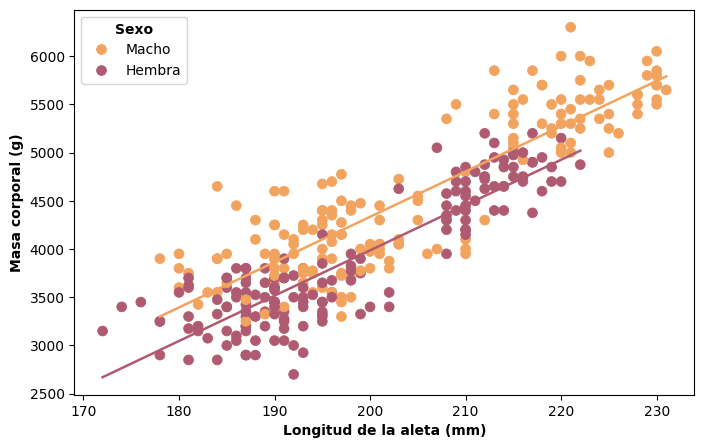

In [19]:
# Primero generamos los valores predichos de la respuesta para los registros del dataset
data_penguins['predichos'] = modelo2.predict(data_penguins)

# Luego los utilizamos para representar las rectas
fig, ax = plt.subplots(figsize = (8, 5))

sns.scatterplot(x = 'flipper_length_mm', y = 'body_mass_g', hue = 'sex', palette = colores, s = 50, data = data_penguins, edgecolor = None, ax = ax)
sns.lineplot(x = 'flipper_length_mm', y = 'predichos', hue = 'sex', palette = colores, linewidth = 1.8, data = data_penguins, ax = ax, legend = False)

ax.set_xlabel('Longitud de la aleta (mm)', fontweight = 'bold')
ax.set_ylabel('Masa corporal (g)', fontweight = 'bold')

handles, _ = ax.get_legend_handles_labels()
ax.legend(title = 'Sexo', handles = handles, labels = ['Macho', 'Hembra'], title_fontproperties = {'weight': 'bold'})

plt.show()

## R<sup>2</sup> ajustado

Al agregar más predictores, la Suma de Cuadrados de Error (SCE) nunca puede aumentar. En el peor de los casos, se mantendrá invariante. Como consecuencia, **el $R^2$ convencional nunca disminuye al incorporar nuevas variables al modelo**, incluso si estas son completamente irrelevantes o puro ruido. Esto lo convierte en una métrica engañosa para comparar modelos con distinto número de predictores.

El **$R^2$ ajustado** corrige este problema penalizando la inclusión de variables innecesarias:

$$R^2_{\text{adj}} = 1 - \frac{\text{SCE}/(n - p - 1)}{\text{SCT}/(n-1)}$$

donde:

- $n$ es el número de observaciones.

- $p$ es el número de predictores en el modelo.

A diferencia del $R^2$ estándar, el $R^2_{\text{adj}}$ **puede disminuir** si la nueva variable no aporta suficiente poder explicativo como para compensar el incremento en $p$. Por lo tanto, es la métrica de elección cuando se realiza selección de variables o comparación de modelos con diferente complejidad.

In [20]:
print(f"""
Modelo 1 — R² ajustado: {modelo.rsquared_adj:.4f}
Modelo 2 — R² ajustado: {modelo2.rsquared_adj:.4f}
""")


Modelo 1 — R² ajustado: 0.9804
Modelo 2 — R² ajustado: 0.8047



## Inferencia sobre los parámetros del modelo

Hasta ahora usamos el modelo ajustado con dos propósitos: describir la relación entre las variables e interpretar los coeficientes estimados. Pero hay una pregunta que aún no respondimos formalmente: **¿podemos confiar en que esos coeficientes reflejan una relación real en el mundo, o podrían ser simplemente el resultado del azar (ruido en los datos)?**

Esta pregunta es el corazón de la inferencia estadística.

### El problema de la muestra y la variabilidad

Los datos con los que ajustamos un modelo son siempre **una muestra de una población más grande.** Si recolectáramos una muestra nueva —otros departamentos, otros pingüinos—, los valores en los datos cambiarían. En consecuencia, al volver a ajustar el modelo obtendríamos valores ligeramente distintos para $\hat{\beta}_0$, $\hat{\beta}_1$, etc. Esto no es un defecto del método sino una consecuencia inevitable de trabajar con datos muestrales.

Aunque asumimos que los verdaderos parámetros poblacionales del modelo ($\beta_0$, $\beta_1$, etc.) son valores fijos y desconocidos, los valores de sus estimadores ($\hat{\beta}_0$, $\hat{\beta}_1$, etc.) cambian de muestra en muestra. Si repitiéramos el proceso de muestreo infinitas veces y ajustáramos el modelo con cada nuevo conjunto de datos, generaríamos una enorme colección de diferentes valores posibles para cada $\hat{\beta}$. Si representáramos todos esos valores en un histograma o un gráfico de densidad, veríamos que algunos resultados ocurren con mucha frecuencia y otros son extremadamente raros. Al comportamiento de esta colección de valores lo llamamos **distribución muestral del estimador $\hat{\beta}$** y es, formalmente, una **distribución de probabilidad**. 

```{admonition} **Importante**
:class: note

Describir matemáticamente la distribución muestral de los estimadores requiere herramientas avanzadas de probabilidad que exceden los objetivos de este módulo. Nuestro foco estará en comprender la intuición detrás de estos conceptos y aprender a interpretar de forma crítica los resultados que nos devuelve el *software*.
```

### Cuantificando la incertidumbre: el error estándar

Para saber qué tan precisa es nuestra estimación, necesitamos medir cuánto variarían esos coeficientes si cambiáramos de muestra. Esa medida de dispersión es el **Error estándar del estimador**, denotado como $SE(\hat{\beta}_j)$.

Un error estándar "pequeño" indica que el estimador es muy estable (baja incertidumbre). n error estándar grande indica que el valor estimado es muy sensible a la muestra particular que nos tocó (alta incertidumbre).

En la salida de `statsmodels`, el error estándar de cada coeficiente aparece en la columna `std err`.

### Prueba de hipótesis sobre los parámetros

Para darle un marco formal a esta evaluación, supongamos que estamos trabajando con un modelo de regresión lineal múltiple con dos predictores:

$$Y = \beta_0 + \beta_1~X_1 + \beta_2~X_2 + \varepsilon$$

Dado que nuestro estimador $\hat{\beta_1}$ tiene variabilidad muestral, surge una pregunta natural: **¿el valor que obtuvimos a partir de nuestra muestra de datos está suficientemente lejos de cero como para concluir que existe una relación real entre $x_1$ e $y$? Si en la población general el verdadero valor fuera $\beta_1 = 0$, significaría que el predictor $x_1$ no tiene ningún efecto lineal sobre la variable respuesta $y$, por lo que su inclusión en el modelo sería innecesaria.

Este dilema se formaliza matemáticamente mediante una **prueba o *test* de hipótesis**. Para evaluar el impacto específico del predictor $x_1$, planteamos:

$$H_0: \beta_1 = 0 \qquad \text{vs.} \qquad H_1: \beta_1 \neq 0$$

- **Hipótesis nula ($H_0$)**: representa el escenario donde el predictor $x_1$ no aporta información nueva para explicar a la variable $y$ (una vez que ya se tiene en cuenta a $x_2$). Si $H_0$ es verdadera, cualquier valor de $\hat{\beta}_1$ distinto de cero que hayamos observado en nuestra muestra se debe puramente al azar del muestreo.

- **Hipótesis alternativa ($H_1$)**: sostiene que existe un efecto lineal real de $x_1$ sobre $y$. Si $H_0$ es falsa, confirmamos que el predictor y la respuesta se relacionan linealmente, justificando su permanencia en el modelo.

Para decidir entre ambas opciones, se evalúa qué tan "lejos"" está el coeficiente estimado $\hat{\beta}_1$ del cero, usando su propia variabilidad como unidad de medida. Esto se calcula mediante el estadístico $t$:

$$t = \frac{\hat{\beta}_1}{SE(\hat{\beta}_1)}$$

Este cociente mide a cuántos errores estándar de distancia se encuentra $\hat{\beta}_1$ del valor planteado por la hipótesis nula ($\beta_1 = 0$). Cuanto mayor sea el valor absoluto de $t$ ($|t|$), más raro sería haber obtenido ese coeficiente por puro azar, aportando mayor evidencia en contra de $H_0$. 

### El valor-$p$

Para tomar la decisión final sobre qué hipótesis respaldar, usamos el valor-$p$ ($p$-value). Antes de dar su definición formal, apelemos a una analogía.

<div style="background-color:rgba(94,129,242,0.5);
padding:12px;
border-radius:8px;
margin-bottom:12px;
color:black;">

**La analogía del adivino**

Imaginemos que conocemos a una persona que dice tener el superpoder de adivinar el color de las cartas de una baraja de póker tradicional al tacto. De entrada, desconfiamos profundamente de tamaña afirmación y asumimos la postura escéptica: que no sabe nada y que su habilidad real es cero. Para probarlo, le damos una carta. Resulta que la adivina. ¿Nos sorprendería automáticamente ese hecho? No mucho, ya que hay un 50% de chances de acertar por pura suerte, en tanto existen solo dos alternativas: rojo o negro.

Pero si le damos a nuestro *adivino en potencia* 10 cartas seguidas y acierta las 10, la situación cambia por completo. La probabilidad de que alguien sin ninguna habilidad logre eso por puro azar es de aproximadamente 0.001 (un 0.1%), el resultado de calcular $\left(\frac{1}{2}\right)^{10}$. Ese número tan diminuto resume lo increíblemente incómodo que resultaría seguir sosteniendo nuestra postura escéptica en esta situación. En ese punto, dejaríamos de atribuirlo a la casualidad y concluiríamos que nuestro adivino declarado tiene una habilidad real.

</div>

<br>

Eso es, en esencia, lo que hace el valor-$p$ en nuestro modelo de regresión.

El punto de partida es siempre el "mundo escéptico" de la hipótesis nula ($H_0$): asumimos, provisionalmente, que el parámetro asociado al predictor en cuestión vale exactamente cero ($\beta_1 = 0$). Luego nos preguntamos: en ese mundo donde la variable no tiene efecto real alguno, ¿cuán probable sería observar, por puro azar de la muestra, una estimación $\hat{\beta}_1$ tan alejada de cero (o más) como la que obtuvimos?

```{admonition} **Definición del valor-$p$**
:class: tip
El valor-$p$ es la probabilidad de obtener, asumiendo que $H_0$ es verdadera, un estadístico $t$ tan extremo como el observado (en valor absoluto), o más extremo aún, por puro efecto de la variabilidad muestral.
```

Su rango de variación va de 0 a 1 (ya que después de todo se trata de una probabilidad) y actúa como un "detector de mentiras" del azar:

- **valor-$p$ pequeño (convencionalmente menor a 0.05)**: sería extremadamente improbable observar un coeficiente así si el predictor no hiciera nada en la realidad. Por lo tanto, el azar "pierde credibilidad": rechazamos $H_0$ y concluimos que el predictor es **estadísticamente significativo.**

- **valor-$p$ "grande" (convencionalmente mayor a 0.05)**: el resultado obtenido es perfectamente compatible con el ruido de una muestra en un mundo donde $\beta_1 = 0$. No tenemos evidencia suficiente para descartar el azar, por lo que no rechazamos $H_0$.

```{admonition} **Dos puntos importantes**
:class: warning

1. **El valor-$p$ NO es la probabilidad de que $H_0$ sea verdadera.** De hecho, desde la perspectiva de la estadística frecuencial, los parámetros del modelo son valores **fijos**, no variables aleatorias. Por lo tanto, no tiene sentido hablar de la "probabilidad de que $\beta_1 = 0$".

    En cambio, el valor-$p$ es la probabilidad de observar nuestros datos *dado que $H_0$ es verdadera*. Un valor-$p$ pequeño no "demuestra" de forma absoluta que $\beta_1 \neq 0$, sino que indica que nuestros datos son muy incompatibles con la hipótesis de que el predictor en cuestión no influye.

2. **El umbral de 0.05 es una convención y se conoce formalmente como nivel de significación ($\alpha$).** Este límite refleja qué tan conservadores queremos ser antes de declarar que una variable aporta información real: en algunos contextos donde se requiere extrema cautela se usan criterios más estrictos ($\alpha = 0.01$), mientras que en fases exploratorias se puede ser más flexible ($\alpha = 0.10$), dependiendo siempre de las consecuencias prácticas de apresurarnos a sacar una conclusión.
```

### Intervalos de confianza

Una forma complementaria —y en muchos sentidos más informativa— de cuantificar la incertidumbre sobre un coeficiente es construir un **intervalo de confianza**.

Un intervalo de confianza del 95% para $\beta_1$ es un rango de valores calculado a partir de nuestra muestra que tiene una propiedad teórica: si repitiéramos el proceso de muestreo infinitas veces y construyéramos un intervalo para cada muestra, el verdadero parámetro poblacional estaría contenido dentro de esos límites el 95% de las veces.

En su cálculo interviene un percentil de la distribución $t$ (que depende del tamaño de la muestra, del número de predictores y del nivel de confianza elegido) y el error estándar estimado del coeficiente.

- **Si el intervalo NO contiene al cero:** significa que el cero no es un valor plausible para el parámetro. Esto es equivalente a rechazar $H_0$ con un valor-$p$ $\leq 0.05$.

- **Si el intervalo CONTIENE al cero:** significa que es perfectamente posible que el verdadero impacto de la variable sea nulo. Esto es equivalente a obtener un valor-$p$ $> 0.05$.

El test de hipótesis y la estimación por intervalo de confianza son dos caras de la misma moneda. Siempre que exista compatibilidad entre el nivel de significación del test y el grado de confianza del intervalo (por ejemplo, un test con $\alpha = 0.05$ frente a un intervalo del $95\%$), ambas herramientas de la inferencia estadística conducirán exactamente a la misma conclusión.

### Ejemplo práctico: el dataset *Advertising*

Una empresa de consumo masivo registró su inversión publicitaria y sus ventas en 200 mercados distintos. Los datos se encuentran en el archivo [advertising.csv](https://drive.google.com/file/d/1tSM-uaRk_oAXKjcpyGrVkU8FUYPJpLSn/view). El objetivo de la empresa es entender cómo impacta el presupuesto destinado a publicidad en tres medios distintos (`TV`, `Radio` y `Newspaper`) sobre las ventas (`Sales`) del producto.

Las variables de presupuesto publicitario están expresadas en miles de dólares y `Sales` está en miles de unidades vendidas.

#### Exploración y validación de los datos

Antes de ajustar cualquier modelo, el primer paso fundamental como científicos de datos es inspeccionar la estructura de nuestro conjunto de datos para verificar que la información sea coherente con el problema planteado. Vamos a cargar el archivo y observar las primeras filas:

In [21]:
import pandas as pd

# Importamos los datos
df = pd.read_csv('datasets/advertising.csv')

# Visualizamos las primeras 5 observaciones
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


Si analizamos, por ejemplo, el mercado cuya información se encuentra en la primera fila, el reporte nos indica que se invirtieron 230100 USD en TV, 37800 USD en radio y 69200 USD en diarios/periódicos, alcanzando un volumen de ventas de 22100 unidades del producto.

Para asegurarnos de que la carga fue completa y que contamos con el volumen de información esperado por la empresa, verificamos las dimensiones del DataFrame:

In [22]:
# Verificamos filas (observaciones) y columnas (variables)
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (200, 4)


El resultado confirma que disponemos de 200 filas (los 200 mercados históricos analizados) y 4 columnas (las tres variables predictoras de inversión y nuestra variable de respuesta). Con los datos correctamente validados, estamos listos para avanzar.

#### Ajuste del modelo múltiple completo y análisis de la salida

Ajustamos un modelo de regresión lineal múltiple utilizando la librería `statsmodels`:

In [23]:
import statsmodels.formula.api as smf

# Ajustamos el modelo lineal múltiple completo: Sales en función de los tres medios
modelo1 = smf.ols(formula = 'Sales ~ TV + Radio + Newspaper', data = df).fit()

# Mostramos el resumen completo
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           8.13e-99
Time:                        17:13:52   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6251      0.308     15.041      0.0

Centraremos nuestra atención sobre la tabla de coeficientes:

In [24]:
# Tabla de coeficientes
coef_table_advertising = modelo1.summary2().tables[1]

# Función para formatear números grandes en notación científica
def fmt(x):
    return f"{x:.3e}" if abs(x) >= 10000 else f"{x:.3f}"

# Construir salida estilo statsmodels
output_coef = """
======================================================================================
                     coef    std err          t      P>|t|        [0.025      0.975]
--------------------------------------------------------------------------------------
"""

for idx, row in coef_table_advertising.iterrows():

    low = fmt(row['[0.025'])
    high = fmt(row['0.975]'])

    output_coef += (
        f"{idx:<12}"
        f"{row['Coef.']:>13.4f}"
        f"{row['Std.Err.']:>11.3f}"
        f"{row['t']:>11.3f}"
        f"{row['P>|t|']:>11.3f}"
        f"{low:>14}"
        f"{high:>13}\n"
    )

output_coef += "======================================================================================"

print(output_coef)


                     coef    std err          t      P>|t|        [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept          4.6251      0.308     15.041      0.000         4.019        5.232
TV                 0.0544      0.001     39.592      0.000         0.052        0.057
Radio              0.1070      0.008     12.604      0.000         0.090        0.124
Newspaper          0.0003      0.006      0.058      0.954        -0.011        0.012


**¿Qué información nos brinda cada columna de este reporte?**

- **`coef`**: la estimación puntual de cada parámetro ($\hat{\beta}_j$).

- **`std err`**: el error estándar estimado ($\widehat{SE}$), que mide la incertidumbre o variabilidad de la estimación.

- **`t`**: el estadístico de la prueba ($t = \hat{\beta}_j / \widehat{SE}$).

- **`P>|t|`**: el valor-$p$ (la probabilidad de que el coeficiente observado sea una mera casualidad del azar).

- **`[0.025 0.975]`**: los límites inferior y superior del intervalo de confianza del 95%.

Si analizamos el comportamiento de cada medio publicitario bajo nuestro nivel de significación convencional ($\alpha = 0.05$), podemos extraer conclusiones sumamente valiosas para la estrategia de la empresa:

- Inversión en `TV`: su coeficiente es de 0.0544. El error estándar es sumamente bajo (0.001), lo que nos da un estadístico $t$ enorme (39.525). Como consecuencia, su valor-$p$ figura como 0.000 (lo que indica que es menor a 0.001, por ende, menor a $\alpha = 0.05$) y su intervalo de confianza [0.052, 0.057] no contiene al cero. Todo coincide de manera consistente: hay evidencia estadística contundente de que la publicidad en `TV` tiene un efecto lineal positivo sobre las ventas.

- Inversión en `Radio`: el coeficiente es de 0.1070 con un valor-$p$ de 0.000. Su intervalo de confianza es [0.090, 0.124], el cual está completamente alejado del cero. Al igual que la `TV`, la `Radio` es un predictor estadísticamente significativo y muy importante para el modelo.

- Inversión en `Newspaper` (prensa escrita): acá ocurre lo más interesante. Su coeficiente estimado es casi cero (0.0003), pero lo crucial es mirar las métricas de inferencia. Su estadístico $t$ es muy bajo (0.057), lo que nos arroja un **valor-$p$ grande de 0.954**. Esto significa que en un mundo donde la publicidad en diarios no genera ningún efecto real, tendríamos un 95.4% de probabilidades de observar un coeficiente como ese (o más extremo) por puro azar del muestreo. Mirando el intervalo de confianza, confirmamos que va desde -0.011 hasta 0.012, es decir, **contiene al cero.**

Bajo la óptica de la inferencia estadística, concluimos que la variable `Newspaper` no aporta información real para explicar las ventas cuando ya se tienen en cuenta las inversiones en `TV` y `Radio`. El resultado que observamos en la muestra es perfectamente compatible con el azar.

Para un científico de datos, esta es la señal formal para tomar una decisión de diseño: podríamos eliminar `Newspaper` del modelo para simplificarlo sin perder poder explicativo (evitando agregar complejidad innecesaria). Para el negocio, sugiere una recomendación directa: la empresa debería reasignar ese presupuesto publicitario hacia los medios que sí demostraron un impacto real.

#### Hacia la simplificación: el modelo reducido

Remover una variable no significativa no es una decisión que se tome a ciegas. Esperamos que al quitar `Newspaper`, el modelo no pierda capacidad explicativa y que, además, mejore su penalización por complejidad. Aquí es donde cobra relevancia la métrica que estudiamos algunos apartados atrás: el $R^2$ ajustado.

Para comprobar si nuestra decisión de diseño es correcta, ajustamos un modelo reducido que excluya a la prensa escrita y conserve únicamente los predictores significativos (`TV` y `Radio`), para luego comparar el comportamiento de ambos.

In [25]:
# Ajustamos el modelo lineal múltiple reducido: Sales en función de TV y Radio
modelo2 = smf.ols(formula = 'Sales ~ TV + Radio', data = df).fit()

# Mostramos el resumen completo
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          2.39e-100
Time:                        17:13:53   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6309      0.290     15.952      0.0

Al revisar la nueva salida, se observa que el $R^2$ ajustado aumenta sutilmente al eliminar Newspaper (pasa de 0.901 a 0.902). Aunque el incremento numérico sea muy leve, el hecho de que no haya disminuido nos confirma formalmente que hicimos bien en prescindir de la incorporación de ese predictor, logrando así un modelo más simple.

<br>

Una vez seleccionado nuestro modelo óptimo, podemos pasar en limpio su ecuación matemática a partir de los nuevos coeficientes estimados:

$$\widehat{\text{Sales}} = 4.6309 + 0.0544 \cdot \text{TV} + 0.1072 \cdot \text{Radio}$$

Para consolidar el entendimiento, pongamos a prueba el modelo con un caso práctico de predicción:

**Desafío de predicción:** supongamos que la empresa planea ingresar a un nuevo mercado y decide invertir 150000 USD en TV, 30000 USD en Radio y 60000 USD en periódicos (Newspaper). ¿Cuáles serían las ventas esperadas?

Aquí es donde la inferencia estadística demuestra su valor práctico para el negocio. Como nuestro análisis demostró que la inversión en prensa escrita no tiene un impacto real sobre las ventas en presencia de los otros medios, los 60000 USD destinados a prensa escrita simplemente se ignoran en el cálculo, ya que no forman parte de la ecuación del modelo óptimo.

Recordando que las variables deben ingresarse en las unidades correctas (en miles de dólares), reemplazamos los valores correspondientes en nuestra fórmula:

$$\widehat{\text{Sales}} = 4.6309 + 0.0544 \cdot (150) + 0.1072 \cdot (30)$$

$$\widehat{\text{Sales}} = 4.6309 + 8.1600 + 3.2160 = 16.0069$$

El modelo predice un volumen de ventas esperado de aproximadamente 16007 unidades para ese mercado. Gracias a la inferencia, no solo obtuvimos una estimación precisa, sino que le ahorramos a la empresa el costo de analizar (o realizar) una inversión ineficiente en medios tradicionales que no aportan valor.

<br>

En la práctica, en lugar de realizar estas cuentas "a mano" sustituyendo los valores en la ecuación matemática, recurrimos al método `.predict()` que nos provee `statsmodels`.

Para hacerlo, primero debemos construir un objeto `DataFrame` (usando la librería Pandas) que contenga los escenarios que queremos evaluar. Es un requisito estricto que los nombres de las columnas coincidan exactamente con los nombres de las variables predictoras que utilizamos al definir la fórmula del modelo:

In [26]:
# Creamos el DataFrame con el nuevo escenario a predecir
# Notar que 'Newspaper' no se incluye porque nuestro modelo óptimo (modelo2) no lo utiliza
nuevo_mercado = pd.DataFrame({
    'TV': [150],
    'Radio': [30]
})

# Realizamos la predicción automática
prediccion = modelo2.predict(nuevo_mercado)
print(f"Ventas predichas (en miles de unidades): {prediccion[0]:.4f}")

Ventas predichas (en miles de unidades): 16.0135


Como se observa, el resultado se corresponde con el que obtuvimos "a mano" a partir de la ecuación del modelo ajustado (la diferencia tiene que ver pura y exclusivamente con el redondeo de las estimaciones de los coeficientes).

## Suavizado y Splines

### Suavizado

El material de esta sección fue extraído de: [http://rafalab.dfci.harvard.edu/dsbook/smoothing.html](http://rafalab.dfci.harvard.edu/dsbook/smoothing.html)

El suavizado es una técnica muy poderosa utilizada en todo el análisis de datos. Otro nombre dado a esta técnica es ajuste de curva. Está diseñado para detectar tendencias en presencia de datos ruidosos en casos en los que la forma de la tendencia es desconocida. El nombre de suavizado proviene del hecho de que, para lograr este objetivo, asumimos que la tendencia es suave, como en una superficie suave. En contraste, el ruido o desviación de la tendencia es impredeciblemente irregular:

![Untitled](./imagenes/Untitled16.png)

Para explicar estos conceptos, nos centraremos primero en un problema con solo un predictor. Específicamente, intentamos estimar la tendencia temporal en el margen de la encuesta de voto popular de EE.UU. en 2008 (diferencia entre Obama y McCain).

Para los fines de este ejemplo, no lo consideremos como un problema de pronóstico. En cambio, simplemente estamos interesados en aprender la forma de la tendencia después de que las elecciones hayan terminado.

Suponemos que para cualquier día dado x, hay una preferencia real entre el electorado $f(x)$, pero debido a la incertidumbre introducida por las encuestas, cada punto de datos viene con un error $\epsilon$. Un modelo matemático para el margen de encuesta observado $Y_i$ es:

$$
Y_i = f(x_i) + \epsilon_i
$$

Consideremos que queremos predecir Y para un día x. Si supiéramos la probabilidad condicional $f(x) = E(Y| X = x)$, la usaríamos. Pero dado que no conocemos esta expectativa condicional, tenemos que estimarla. Utilicemos regresión, ya que es el método que hemos aprendido hasta ahora.

![Untitled](./imagenes/Untitled17.png)

La línea que vemos no parece describir muy bien la tendencia. Por ejemplo, el 4 de septiembre (día -62) se llevó a cabo la Convención Republicana y los datos sugieren que le dio un impulso a John McCain en las encuestas. Sin embargo, la línea de regresión no captura esta posible tendencia. Para ver la falta de ajuste con mayor claridad, observamos que los puntos por encima de la línea ajustada (azul) y los puntos por debajo (rojo) no están distribuidos de manera uniforme a lo largo de los días. Por lo tanto, necesitamos un enfoque alternativo y más flexible.

### Suavizado por segmentos

La idea general del suavizado es agrupar los puntos de datos en estratos en los cuales se puede suponer que el valor de $f(x)$ es constante. Podemos hacer esta suposición porque pensamos que  $f(x)$ cambia lentamente y, como resultado, $f(x)$ es casi constante en pequeñas ventanas de tiempo. Un ejemplo de esta idea para los datos de encuesta_2008 es asumir que la opinión pública se mantuvo aproximadamente igual durante una semana. Con esta suposición en su lugar, tenemos varios puntos de datos con el mismo valor esperado.

Si fijamos un día para que esté en el centro de nuestra semana, llamémoslo $x_0$, entonces para cualquier otro día $x$ tal que, asumimos que $f(x)$ es una constante $f(x) = \mu$. Esta suposición implica que:

$$
E[Y_i|X_i = x_i] \approx \mu if |x_i - x_0| \le 3.5
$$

En el suavizado, llamamos al tamaño del intervalo que satisface $|x_i - x_0| \le 3.5$ el tamaño de la ventana, ancho de banda o rango. Más adelante veremos que intentamos optimizar este parámetro.

Esta suposición implica que una buena estimación para $f(x)$ es el promedio de los valores $Y_i$ en la ventana. Si definimos $A_0$ como el conjunto de índices $i$ tal que $|x_i - x_0| \le 3.5$ y $N_0$ como el número de índices en $A_0$, entonces nuestra estimación es:

$$
\hat{f}(x_0) = \frac{1}{N_0} \sum_{i\in A_0}{}{Y_i}
$$

La idea detrás del suavizado por segmento es realizar este cálculo con cada valor de $x$ como centro. En el ejemplo de la encuesta, para cada día, calcularíamos el promedio de los valores dentro de una semana con ese día en el centro. Aquí hay dos ejemplos: $x_0 = -125$ y $x_0 = -55$. El segmento azul representa el promedio resultante.

![Untitled](./imagenes/Untitled18.png)

Al calcular esta media para cada punto, formamos una estimación de la curva subyacente $f(x)$. A continuación, mostramos el procedimiento a medida que nos desplazamos desde -155 hasta 0. En cada valor de $x_0$, mantenemos la estimación y pasamos al siguiente punto, el resultado final es el siguiente

![Untitled](./imagenes/Untitled19.png)

### Kernels

El resultado final del suavizado por segmento es bastante irregular. Una razón de esto es que cada vez que la ventana se mueve, dos puntos cambian. Podemos atenuar esto en cierta medida tomando promedios ponderados que otorgan más peso al punto central que a los puntos lejanos, y los dos puntos en los extremos reciben muy poco peso.

Podemos pensar en el enfoque del suavizado por segmentos como un promedio ponderado:

$$
\hat{f}(x_0) = \sum_{i=1}^{N}{w_0 (x_i)Y_i}
$$

en el cual cada punto recibe un peso de 0 o $1/N_0$, siendo $N_0$ el número de puntos en la semana. Las imágenes de abajo muestran dos maneras de ponderar los datos, a la izquierda vemos una forma uniforme o sin ponderación y a la derecha una forma normal.

Si usamos la ponderación normal obtenemos una imagen como la de abajo:

![Untitled](./imagenes/Untitled20.png)

A continuación un ejemplo de suavizado por Kernel, usando la forma Box y Normal:

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# Creamos algunos datos
np.random.seed(0)
X = np.concatenate((np.random.normal(0, 1, 100), np.random.normal(5, 1, 100)))[:, np.newaxis]

# Creamos los modelos de suavizado por kernel
kde_gauss = KernelDensity(kernel='gaussian', bandwidth=0.75).fit(X)
kde_box = KernelDensity(kernel='tophat', bandwidth=0.75).fit(X)  # 'tophat' es un kernel box

# Creamos una serie de puntos donde evaluaremos las densidades
X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]

# Calculamos las densidades
dens_gauss = np.exp(kde_gauss.score_samples(X_plot))  # Usamos exp porque score_samples devuelve el logaritmo de la densidad
dens_box = np.exp(kde_box.score_samples(X_plot))

# Graficamos los resultados
plt.figure(figsize=(10, 6))
plt.plot(X_plot[:, 0], dens_gauss, label="Kernel Gaussiano", color='blue')
plt.plot(X_plot[:, 0], dens_box, label="Kernel Box", color='red')
plt.hist(X, bins=30, density=True, alpha=0.5)
plt.legend()
plt.title("Comparación de suavizado por kernel: Gaussiano vs. Box")
plt.show()
```

En este ejemplo, generamos dos conjuntos de datos a partir de distribuciones normales con medias 0 y 5. Luego creamos dos modelos de s44uavizado por kernel, uno con un kernel Gaussiano y otro con un kernel box, y calculamos las densidades en un conjunto de puntos que abarcan el rango de los datos. Por último, graficamos las densidades calculadas junto con un histograma de los datos.

![Untitled](./imagenes/Untitled21.png)

### Regresión Local Ponderada (loess)

Una limitación del enfoque del suavizado por bin descrito anteriormente es que necesitamos ventanas pequeñas para que las suposiciones de aproximada constancia se cumplan. Como resultado, terminamos con un pequeño número de puntos de datos para promediar y obtener estimaciones imprecisas $\hat{f}(x)$. Aquí describimos cómo la regresión ponderada local (loess) nos permite considerar tamaños de ventana más grandes. Para hacer esto, utilizaremos un resultado matemático conocido como el teorema de Taylor, que nos dice que si examinas lo suficientemente de cerca cualquier función suave $f(x)$, se verá como una línea. 

<aside>
💡 LOESS (LOcally Estimated Scatterplot Smoothing) y LOWESS (LOcally WEighted Scatterplot Smoothing) son esencialmente lo mismo. Ambos son métodos de suavizado que utilizan regresiones lineales ponderadas localmente para suavizar datos. La única diferencia entre los dos términos es más bien histórica y proviene de diferentes comunidades de investigación. LOESS se utiliza a menudo en el campo de la estadística, mientras que LOWESS se utiliza a menudo en el campo de la informática.

</aside>

En lugar de asumir que la función es aproximadamente constante en una ventana, asumimos que la función es localmente lineal. Podemos considerar tamaños de ventana más grandes con la suposición lineal que con una constante. En lugar de la ventana de una semana, consideramos una más grande en la cual la tendencia es aproximadamente lineal. Comenzamos con una ventana de tres semanas y luego consideramos y evaluamos otras opciones.

$$
E[Y_i| X_i = x_i] = \beta_0 + \beta_1 (x_i - x_0) \;\; if \;\; |x_i - x_0| \le 21
$$

Para cada punto $/x_0$, loess define una ventana y ajusta una línea dentro de esa ventana. Aquí hay un ejemplo que muestra los ajustes para x0 = -125 y x0 = -55:

![Untitled](./imagenes/Untitled22.png)

El valor estimado para $x_0$ se convierte en nuestra estimación $\hat{f}(x_0)$. Abajo se muestran los resultados para diferentes spans:

![Untitled](./imagenes/Untitled23.png)

<aside>
💡 La principal ventaja de LOESS sobre el suavizado por segmentos es su flexibilidad. Puede manejar relaciones más complejas y no lineales entre las variables, mientras que el suavizado por segmentos puede estar limitado en este aspecto, especialmente si la elección de los puntos de quiebre o segmentos no es adecuada. Además, LOESS tiende a ser menos susceptible al sobreajuste que el suavizado por segmentos, especialmente si se elige un valor adecuado para el parámetro de suavizado.

</aside>

A continuación se muestra un ejemplo de suavizado con LOESS, usando **`statsmodels`** y utilizando el conjunto de datos de iris incorporado en **`seaborn`**:

```python
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el conjunto de datos de iris
iris = sns.load_dataset('iris')

# Establecemos nuestros valores x e y
x = iris['sepal_length']
y = iris['petal_length']

# Realizamos el ajuste de la regresión LOWESS con diferentes valores para frac
smoothed_1 = lowess(y, x, frac=0.2)  # 20% de los datos para el ajuste
smoothed_2 = lowess(y, x, frac=0.5)  # 50% de los datos para el ajuste

# Creamos la gráfica
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Datos originales', color='blue')
plt.plot(smoothed_1[:, 0], smoothed_1[:, 1], color='red', label='LOWESS 0.2')
plt.plot(smoothed_2[:, 0], smoothed_2[:, 1], color='green', label='LOWESS 0.5')
plt.legend()
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.title('Ejemplo de ajuste de LOWESS con diferentes factores de suavizado en Python')
plt.show()
```

El resultado es el siguiente:

![Untitled](./imagenes/Untitled24.png)

### Parábolas de ajuste

El teorema de Taylor también nos dice que si observas una función matemática lo suficientemente de cerca, se parece a una parábola. El teorema también establece que no es necesario observar tan de cerca al aproximar con parábolas como cuando se aproxima con líneas. Esto significa que podemos hacer nuestras ventanas aún más grandes y ajustar parábolas en lugar de líneas.

$$
E[Y_i|X_i = x_i] = \beta_0 + \beta_1 (x_i - x_0) + \beta_2 (x_i - x_0)^2 \;\; if \;\; |x_i - x_0| \le h
$$

La imagen de abajo muestra una comparación de las líneas de ajuste (rojo discontinuo) y las parábolas de ajuste (naranja sólido):

![Untitled](./imagenes/Untitled25.png)

## Splines polinómicas

Una spline polinómica es una función matemática que está definida de a segmentos. Esto último quiere decir que para cada intervalo de datos vamos a tener una función polinómica de grado k que los represente. Esta función es continua y suave, es decir, tiene derivadas continuas en los órdenes k-1. Si bien pueden generarse splines de diferentes grados, la más utilizada es la cúbica. 

Las splines se utilizan en interpolación, splines de interpolación, ya que nos permiten obtener una función que pase por todos los puntos de interés. En la imagen de abajo, [link](https://www.youtube.com/watch?v=queK1reC-ac&ab_channel=BrianZaharatos), vemos en línea de trazos una spline que puede servirnos para interpolación. Sin embargo, esta función, probablemente, no será muy útil para modelar nuestros datos puesto que claramente esta haciendo un overfitting de los mismos. Para el modelado de los datos se utiliza una spline suave, dibujado con un trazo lleno abajo.

![Untitled](./imagenes/Untitled26.png)

Para obtener la spline suave vamos a minimizar la siguiente función:

$$
L = \sum_{i = 1}^{n}[y_i - f(x)]^2 + \lambda \int [f''(x)]^2dx 
$$

La primera parte de la función son los mínimos cuadrados que utilizamos para estimar los parámetros de la regresión lineal. La segunda parte de la función, es un término de regulación o penalización. Nosotros queremos tener una función $f(x)$ que tenga cierta curvatura pero no queremos que la misma sea demasiado grande para que no copie los datos y produzca un overfit. Entonces, incorporamos este término al loss/costo, funciones con mayor curvatura van a generar más loss/costo. El parámetro $\lambda$ regula la importancia del término de penalización:

- $\lambda = 0$, implica que no vamos a realizar una penalización por curvatura y por lo tanto el resultado que obtenemos es una spline de interpolación
- $\lambda > 0$, implica que vamos a considerar cierta penalización sobre las funciones con mayor curvatura
- $\lambda = \infty$, implica que la penalización es lo más importante y por lo tanto tendremos una recta horizontal

Para poder estimar las splines en python podemos usar el paquete scipy, [el ejemplo de su documentación](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.UnivariateSpline.html)

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# Generamos los datos de prueba, agregando ruido aleatorio
rng = np.random.default_rng()
x = np.linspace(-3, 3, 50)
y = np.exp(-x**2) + 0.1 * rng.standard_normal(50)
plt.plot(x, y, 'ro', ms=5)

spl = UnivariateSpline(x, y) # s = len data, the default
xs = np.linspace(-3, 3, 1000)
plt.plot(xs, spl(xs), 'g', lw=3)

spl.set_smoothing_factor(2)
plt.plot(xs, spl(xs), 'pink', lw=3)

spl.set_smoothing_factor(0.5)
plt.plot(xs, spl(xs), 'orange', lw=3)

spl.set_smoothing_factor(0)
plt.plot(xs, spl(xs), 'b', lw=3)
plt.show()
```

Cuando usamos un $\lambda$, también llamado término de suavizado, igual a 0, obtenemos la spline de interpolación, en azul. A medida que vamos incrementando el valor de $\lambda$ obtenemos una función con cada vez menos curvatura.

![Untitled](./imagenes/Untitled27.png)

Esto que vimos arriba se llama regresión **no paramétrica** puesto que nosotros no sabemos cuál va a ser la función antes de la estimación, en contraste con la regresión lineal, paramétrica, donde sabíamos la forma de nuestra función y los parámetros que íbamos a estimar. 

## Evaluación del modelo

La regresión es importante y conocer las métricas que se utilizan nos ayudan a entender su comportamiento y saber que tan correcta es. Lamentablemente mucha gente sólo usa un par de métricas, muchas veces debido al desconocimiento de todas las que tenemos disponibles. Ahora veremos diferentes métricas en regresión para que podamos usarlas en nuestros proyectos.

El error es un concepto muy sencillo, simplemente es la diferencia que existe entre el valor que nuestro modelo ha predicho y el valor real de la observación con la que estamos haciendo el test.

![Untitled](./imagenes/Untitled28.png)

### $R^2 - ajustado$

Cuando tenemos más de una variable independiente es recomendable utilizar el $R^2 - ajustado$. La razón para esto último se debe a que a medida que incorporamos más variables explicativas, el $R^2$ va a aumentar, aunque sea de modo marginal, y puede confundir nuestra percepción. Es decir, puede parecernos que el modelo tiene un buen ajuste, pero este no se debe a que se seleccionaron buenas variables sino, a que se incorporaron muchas variables. 

$$
R^2-ajustado = 1-[\frac{(1-R^2)(n-1)}{n-p-1}]
$$

Donde:

$R^2$: coeficiente de determinación

$n$: número de datos en la muestra

$p$: cantidad de variables independientes

En la fórmula de arriba podemos observar que cuando aumentamos el número de variables explicativas en nuestro modelo, más se penalizará el valor del $R^2$. 

### valor-$p$ (p-value) e Intervalo de confianza

El valor p nos sirve para determinar si una variable es estadísticamente significativa o no. Cuando estimamos el coeficiente de una variable en realidad estamos estimando el valor esperado del mismo, osea, ese coeficiente tiene una distribución normal con su media y su varianza. No vamos a entrar en detalles sobre porqué sucede esto porque está fuera del alcance de nuestro curso. Sin embargo, la siguiente imagen puede darnos una intuición sobre lo que sucede. Los datos que nosotros obtenemos para realizar nuestro modelo son una muestra de la realidad. Por ejemplo, si tenemos un dato de precio de alquiler donde un departamento de 60$[m^2]$ cuesta 100.000 $[\$]$ eso no quiere decir que todos los departamentos de 60 $[m^2]$ van a costar lo mismo. Probablemente, haya otros departamentos con la misma superficie que cuesten más o menos, y tal vez, en nuestra muestra no tenemos esos datos recolectados. Por esa razón, cuando estimamos nuestro modelo, en lugar de estimar un valor para cada coeficiente estimamos su media y alguna información sobre su distribución.

image from: An Introduction to Mathematical Statistics and Its Applications. Larsen, R. and Marx, M. 2012

![Untitled](./imagenes/Untitled30.png)

Esta situación nos permite hacer inferencias sobre los coeficientes que estamos estimando, es decir, podemos calcular un intervalo de confianza para los mismos. Si dentro de nuestro intervalo encontramos al valor 0, entonces, puede ser que nuestro coeficiente sea 0, y por lo tanto, no sea de gran valor para explicar a nuestra variable dependiente y. 

Por otro lado, el valor p indica la probabilidad de haber obtenido un coeficiente diferente de cero para cierta variable independiente, cuando en efecto, el coeficiente debía ser cero, y por lo tanto, la variable en cuestión, no es un buen predictor para nuestra variable dependiente. Si bien es un poco más difícil de entender, este valor es más rápido de evaluar.

En el ejemplo de abajo vemos que la probabilidad de que el coeficiente para la variable `fem_dummy` sea igual a 0 es 3.2%.

![Untitled](./imagenes/Untitled31.png)

Los valores p en un modelo de regresión lineal tienen una importancia significativa, ya que ofrecen una forma de evaluar si las variables independientes en el modelo tienen un efecto estadísticamente significativo en la variable dependiente. Los valores p son importantes principalmente por los siguientes motivos:

**Prueba de Hipótesis:**

Los valores p están relacionados con la [prueba de hipótesis en la estadística](https://es.wikipedia.org/wiki/Contraste_de_hip%C3%B3tesis). Para cada coeficiente en el modelo de regresión, se realiza una prueba de hipótesis para evaluar si el coeficiente es diferente de cero.

- **Hipótesis Nula**: El coeficiente es igual a cero, lo que significa que la variable independiente correspondiente no tiene ningún efecto en la variable dependiente.
- **Hipótesis Alternativa**: El coeficiente es diferente de cero, lo que significa que la variable independiente correspondiente tiene un efecto en la variable dependiente.

**Significancia Estadística:**

Un valor p es una medida de evidencia en contra de la hipótesis nula. Un valor p pequeño (por lo general, menor que 0.05) indica que hay evidencia fuerte en contra de la hipótesis nula, y por lo tanto, se rechaza.

- Si el valor p es pequeño, concluimos que la variable independiente correspondiente tiene un efecto significativo en la variable dependiente.
- Si el valor p es grande, no hay suficiente evidencia para rechazar la hipótesis nula, y no podemos concluir que la variable independiente tenga un efecto en la variable dependiente.

**Selección de Variables:**

Los valores p pueden ser útiles en la selección de variables en un modelo de regresión. Las variables con valores p bajos son más propensas a ser importantes en la predicción de la variable dependiente. Eliminar variables con valores p altos puede llevar a un modelo más simple y más interpretable sin sacrificar mucho en términos de ajuste.

### **Error absoluto medio, mean absolute error (MAE)**

Esta métrica es una medida de la diferencia entre dos valores, es decir, nos permite saber que tan diferente es el valor predicho y el valor real u observado. Para que un error con valor positivo no cancele a un error con error negativo usamos el valor absoluto de la diferencia. Como nos interesa conocer el comportamiento del error de todas las observaciones y no solamente de una, entonces obtenemos el promedio de los valores absolutos de la diferencia.

$$
MAE = \frac{1}{n}\sum_{i = 1}^{n}|y_i - \hat{y_i}|
$$

Este coeficiente mide la media de la distancia absoluta entre los valores reales y estimados de la variable dependiente $y$

Supongamos que tenemos las siguientes observaciones, representan a los valores reales u observados.

Reales=[3, 2.5, -2, 2.3, 4, 7.2, 8.1]

Y los valores a continuación representan los que nos da nuestro modelo.

Modelo=[3.1, 2.5, -2.5, 2.45, 3.8, 7.8, 7.9]

Ahora calculamos el MAE y el valor que obtenemos es de **0.249**, es decir que de todos los errores en las observaciones, el error promedio es de **0.249**

### **Error medio cuadrado, mean square error (MSE)**

Esta métrica es muy útil para saber que tan cerca es la línea de ajuste de nuestra regresión a las observaciones. Al igual que en caso anterior evitamos que un error con valor positivo anule a uno con valor negativo, pero en lugar de usar el valor absoluto, elevamos al cuadrado la diferencia.

Siempre nos da un valor positivo y entre más cercano sea a cero es mejor. Se define como:

$$
MSE = \frac{1}{n}\sum_{i = 1}^{n}(y_i - \hat{y_i})^2
$$

<aside>
💡 MAE es más robusto cuando los datos tienen outliers o datos atípicos y es la mejor opción a usar en esos casos. Otra ventaja del MAE es que su escala es la misma que la de los datos de destino, lo que hace que sea fácil de interpretar.

</aside>

Este coeficiente mide la media de la distancia cuadrada entre los valores reales y estimados de la variable dependiente $y$. 

<aside>
💡 El MSE da más peso a los errores grandes, es decir, penaliza más los errores grandes.

</aside>

En nuestro ejemplo anterior, al calcular el MSE obtenemos **0.103**, algo que no tenemos que olvidar es que el valor que obtenemos esta en **unidades cuadradas**.

Los coeficientes MAE y MSE dan una medida de la performance del modelo. Valores más altos indican que los datos se encuentran más alejados del modelo, y por lo tanto, este último, puede no ser una buena representación para los mismos. 

## Regresión lineal múltiple

La regresión lineal múltiple es un método estadístico que permite examinar la relación entre dos o más variables explicativas y una variable respuesta. Es una extensión del modelo de regresión lineal simple, que sólo permite una variable explicativa.

El modelo de regresión lineal múltiple se expresa de la siguiente forma:

$$
y = a + b_1 x_1 + b_2x_2 + ...+b_nx_n + \epsilon
$$

En esta ecuación vamos a estimar una constante y un parámetro para cada una de las n variables explicativas.

Donde:

- Y es la variable respuesta (la que queremos predecir o explicar)
- X1, X2, ..., Xn son las variables explicativas o independientes
- b0, b1, ..., bn son los coeficientes de regresión, que se estiman a partir de los datos. Estos indican el efecto que tiene cada variable independiente en la variable dependiente.
- e es el error aleatorio

Los coeficientes de regresión (b0, b1, ..., bn) se interpretan de la siguiente manera:

- b0 es la ordenada en el origen, es decir, el valor esperado de Y cuando todas las variables explicativas son cero.
- b1 es la variación en Y asociada a una variación de una unidad en X1, manteniendo constantes las demás variables explicativas.
- En general, cada coeficiente bi (i>0) es la variación en Y asociada a una variación de una unidad en Xi, manteniendo constantes las demás variables.

Los coeficientes se suelen estimar a través del método de mínimos cuadrados ordinarios (MCO), que minimiza la suma de los cuadrados de las diferencias entre los valores observados y los valores predichos de la variable dependiente.

## Ejemplo

El primer ejemplo que les aconsejamos revisar es el visto en clase, que se encuentra en la notebook, donde predecimos los costos de obra social.

Otro ejemplo en Python, usando stats model, podría ser el siguiente, una predicción de precios de casas a partir de un dataset con múltiples características de viviendas:

- Avg. Area Income: es el ingreso promedio de las personas que viven en esta área.
- Avg. Area House Age: es la edad promedio de las casas ubicadas en el área.
- Avg. Area Number of Rooms: es el número promedio de habitaciones de las casas en esta área.
- Avg. Area Number of Bedrooms: es el número promedio de dormitorios de las casas en esta área.
- Area Population: Población del área.
- Address: es la dirección de la casa.

En nuestro ejemplo, estamos usando esas variables (salvo Address) para entrenar el modelo.

```python
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

df = pd.read_csv('https://raw.githubusercontent.com/connectaditya/House-price-prediction/master/USA_Housing.csv')

# Definir las variables independientes y la dependiente
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 
        'Avg. Area Number of Bedrooms', 'Area Population']]
Y = df['Price']

# Agregar una constante a las variables independientes (intercepto)
X = sm.add_constant(X)

# Crear y entrenar el modelo usando statsmodels
model = sm.OLS(Y, X).fit()

# Imprimir el resumen del modelo, incluyendo coeficientes y valores-p
print(model.summary())
```

Este código utiliza `summary()`, que nos dará un resumen completo del modelo de regresión, incluyendo estadísticas como los coeficientes, los valores t, los valores p, el R², etc. 

```
OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     9044.
Date:                Sat, 12 Aug 2023   Prob (F-statistic):               0.00
Time:                        23:16:18   Log-Likelihood:                -51755.
No. Observations:                4000   AIC:                         1.035e+05
Df Residuals:                    3994   BIC:                         1.036e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                        -2.647e+06   1.91e+04   -138.228      0.000   -2.68e+06   -2.61e+06
Avg. Area Income                21.6604      0.149    144.946      0.000      21.367      21.953
Avg. Area House Age           1.658e+05   1598.673    103.717      0.000    1.63e+05    1.69e+05
Avg. Area Number of Rooms     1.203e+05   1779.180     67.632      0.000    1.17e+05    1.24e+05
Avg. Area Number of Bedrooms  2193.0956   1461.592      1.500      0.134    -672.440    5058.631
Area Population                 15.2859      0.161     94.837      0.000      14.970      15.602
==============================================================================
Omnibus:                        4.735   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.094   Jarque-Bera (JB):                4.353
Skew:                          -0.034   Prob(JB):                        0.113
Kurtosis:                       2.854   Cond. No.                     9.42e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.42e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
```

Un valor de R² más cercano a 1 indica que el modelo es capaz de explicar una gran proporción de la variación en la variable dependiente. Un valor de R² más cercano a 0, por otro lado, indica que el modelo no puede explicar mucha variación en la variable dependiente. En nuestro caso, hemos obtenido un modelo con R² igual a 0.91 😉

<aside>
💡 Los valores p en particular nos ayudarán a determinar si cada variable independiente es estadísticamente significativa en la predicción de la variable dependiente. Un valor p menor que un nivel de significancia típico (como 0.05) sugiere que hay evidencia fuerte contra la hipótesis nula, lo que indica que la característica es relevante para el modelo.

</aside>

### Representación gráfica

En regresiones lineales múltiples, se vuelve complicado visualizar el modelo en un gráfico debido a que tenemos más de dos dimensiones (cada variable independiente añade una dimensión). En cambio, podríamos visualizar la relación entre la variable dependiente y cada una de las variables independientes individualmente.

Sin embargo, para visualizar la precisión del modelo, se puede usar un gráfico de dispersión que compara los valores reales de la variable dependiente en el conjunto de prueba con los valores predichos por el modelo. Idealmente, estos valores deberían estar cerca de una línea diagonal, que representa la perfección (es decir, la predicción es exactamente igual al valor real). Aquí tenemos un ejemplo de cómo hacer esto en Python con `matplotlib`:

```python
import matplotlib.pyplot as plt

plt.scatter(Y_test, Y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Valores Reales vs Predicciones')

# Dibujar la línea de perfección
diagonal = np.linspace(min(Y_test.min(), Y_pred.min()), max(Y_test.max(), Y_pred.max()))
plt.plot(diagonal, diagonal, '-r')
plt.show()
```

El resultado será el siguiente:

![Untitled](./imagenes/Untitled32.png)

Este gráfico ayudará a visualizar cómo de cerca están las predicciones de los valores reales. Si el modelo es perfecto, todos los puntos estarían sobre la línea roja. Desviaciones de esta línea representan errores en la predicción.

## Un buen resumen de lo que vimos

Este [post](https://mlu-explain.github.io/linear-regression/) es un buen resumen de todos los temas que estuvimos viendo de regresión lineal en esta unidad. 

# Referencias no listadas anteriormente

(1) Introduction to Modern Statistics Mine Çetinkaya-Rundel and Johanna Hardin

[https://www.youtube.com/watch?v=queK1reC-ac](https://www.youtube.com/watch?v=queK1reC-ac)

LINEAR REGRESSION - A Visual Introduction To (Almost) Everything You Should Know: [https://mlu-explain.github.io/linear-regression/](https://mlu-explain.github.io/linear-regression/)